In [ ]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Pandas         : 2.2.2
NumPy          : 2.0.2
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2


In [ ]:
import pandas as pd
import seaborn as sns
from pandas import read_csv
df=read_csv("/content/placement_predict_50k Dataset (1).csv")

In [ ]:
df['StudentID']
df.shape

(50000, 31)

In [ ]:
df.dtypes

,0
StudentID,int64
Gender,object
City,object
CollegeTier,object
Stream,object
Specialisation,object
Hostel,object
HistoryOfBacklogs,object
SGPA_Sem1,float64
SGPA_Sem2,float64


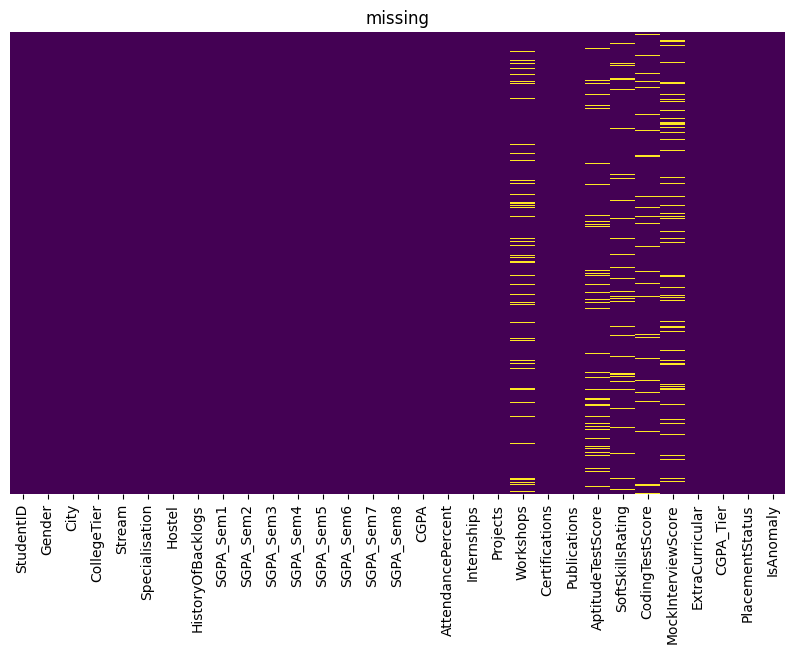

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# cbar=False hides the color bar; yticklabels=False hides row numbers for cleaner v
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("missing")
plt.show()

In [ ]:
#Keeps the first occurrence and marks subsequent duplicates as True(if any)
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)
print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [StudentID, Gender, City, CollegeTier, Stream, Specialisation, Hostel, HistoryOfBacklogs, SGPA_Sem1, SGPA_Sem2, SGPA_Sem3, SGPA_Sem4, SGPA_Sem5, SGPA_Sem6, SGPA_Sem7, SGPA_Sem8, CGPA, AttendancePercent, Internships, Projects, Workshops, Certifications, Publications, AptitudeTestScore, SoftSkillsRating, CodingTestScore, MockInterviewScore, ExtraCurricular, CGPA_Tier, PlacementStatus, IsAnomaly]
Index: []

[0 rows x 31 columns]
----------------------------------------


In [ ]:
#display rows where null values are present if any
df[df['AptitudeTestScore'].isnull()]

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
7,8,Male,Delhi,Tier2,Mechanical,Embedded,Yes,No,5.87,5.64,...,0,0,NaN,2.0,35.2,27.8,0,Low,0,0
13,14,Male,Delhi,Tier1,CS,AI,No,No,10.00,10.00,...,3,1,NaN,NaN,87.9,86.8,1,High,1,0
18,19,Male,Bangalore,Tier2,Mechanical,Embedded,No,No,6.97,6.53,...,1,0,NaN,1.3,57.9,56.6,0,Mid,0,0
29,30,Female,Pune,Tier2,Civil,Networking,Yes,No,9.94,9.85,...,3,2,NaN,4.8,60.3,89.3,1,High,1,0
33,34,Male,Kochi,Tier3,Civil,AI,Yes,No,4.52,4.06,...,1,1,NaN,2.1,27.4,34.6,1,Low,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49935,49936,Male,Bangalore,Tier3,ECE,Embedded,No,No,5.73,5.73,...,0,1,NaN,2.0,28.6,32.5,0,Low,0,0
49943,49944,Male,Jaipur,Tier3,CS,DataScience,No,Yes,5.28,5.53,...,0,0,NaN,NaN,NaN,26.0,0,Low,0,0
49947,49948,Female,Bangalore,Tier1,CS,Networking,No,No,9.75,10.00,...,4,1,NaN,4.2,55.6,63.1,1,High,1,0
49961,49962,Male,Delhi,Tier2,CS,DataScience,Yes,No,7.10,7.00,...,3,2,NaN,NaN,98.5,75.7,1,Mid,1,0


In [ ]:
#  Checking for Duplicates

df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df.describe()

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,45512.000000,50000.000000,50000.000000,45971.000000,46474.000000,47024.000000,45043.00000,50000.000000,50000.000000,50000.000000
mean,25000.500000,7.210583,7.222243,7.235398,7.247290,7.258639,7.274511,7.282720,7.293704,7.246154,...,1.804469,1.931420,0.735460,68.859261,3.154211,57.411273,55.40853,0.533000,0.657120,0.035000
std,14433.901067,1.517846,1.532008,1.551632,1.570629,1.587829,1.603261,1.621605,1.638112,1.615686,...,1.036193,1.175391,0.717167,15.365230,0.981333,20.979679,17.52218,0.498915,0.474677,0.183782
min,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,15.90000,0.000000,0.000000,0.000000
25%,12500.750000,6.090000,6.090000,6.080000,6.070000,6.070000,6.080000,6.060000,6.060000,6.040000,...,1.000000,1.000000,0.000000,58.500000,2.400000,45.900000,44.20000,0.000000,0.000000,0.000000
50%,25000.500000,7.190000,7.210000,7.220000,7.240000,7.260000,7.280000,7.300000,7.310000,7.250000,...,2.000000,2.000000,1.000000,69.900000,3.200000,57.700000,54.70000,1.000000,1.000000,0.000000
75%,37500.250000,8.340000,8.360000,8.400000,8.430000,8.460000,8.500000,8.520000,8.560000,8.480000,...,3.000000,3.000000,1.000000,79.700000,3.900000,73.300000,69.20000,1.000000,1.000000,0.000000
max,50000.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,4.000000,5.000000,3.000000,100.000000,5.000000,100.000000,100.00000,1.000000,1.000000,1.000000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
df = pd.read_csv("placement_predict_50k Dataset (1).csv")

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.921


In [1]:

from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts

In [5]:

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")


In [6]:

print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,2,0,66.7,2.2,49.4,47.8,0,Low,0,0
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,1,0,48.2,2.4,26.7,25.8,0,Low,0,0
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,1,0,73.8,2.8,67.7,41.5,0,Low,1,0
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,2,0,69.8,2.7,66.9,48.0,0,Mid,1,0
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,4,1,73.1,2.1,71.7,61.7,1,High,1,0


In [7]:
print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())


Shape of dataset (rows, columns): (50000, 31)

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  ob

In [8]:

df['Placed_Flag'] = df['PlacementStatus'].apply(lambda x: 1 if x == 'Placed' else 0)

In [9]:

num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']

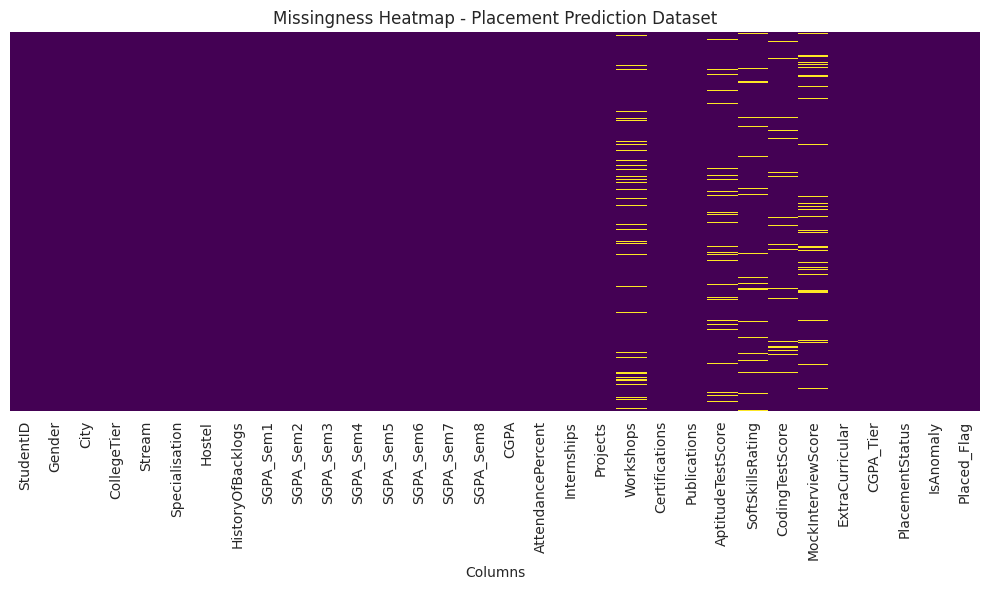

In [10]:

fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

KeyError: 'Salary Package'

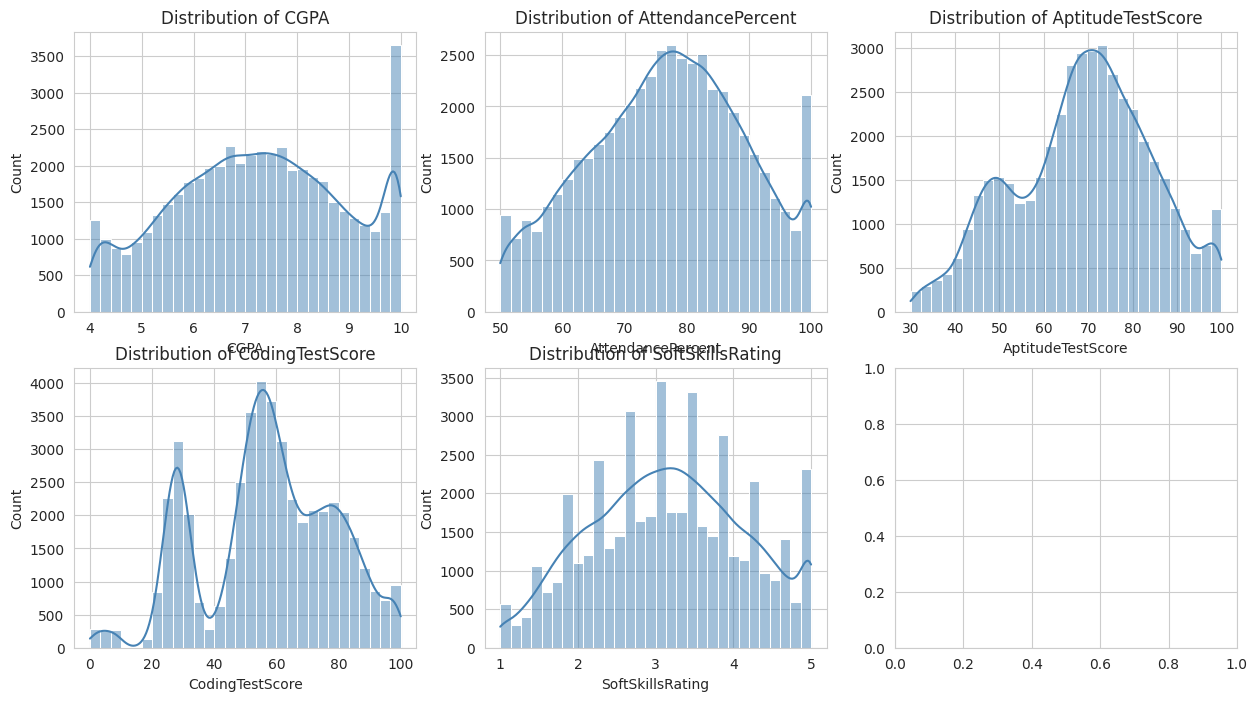

In [11]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1338/449728578.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')


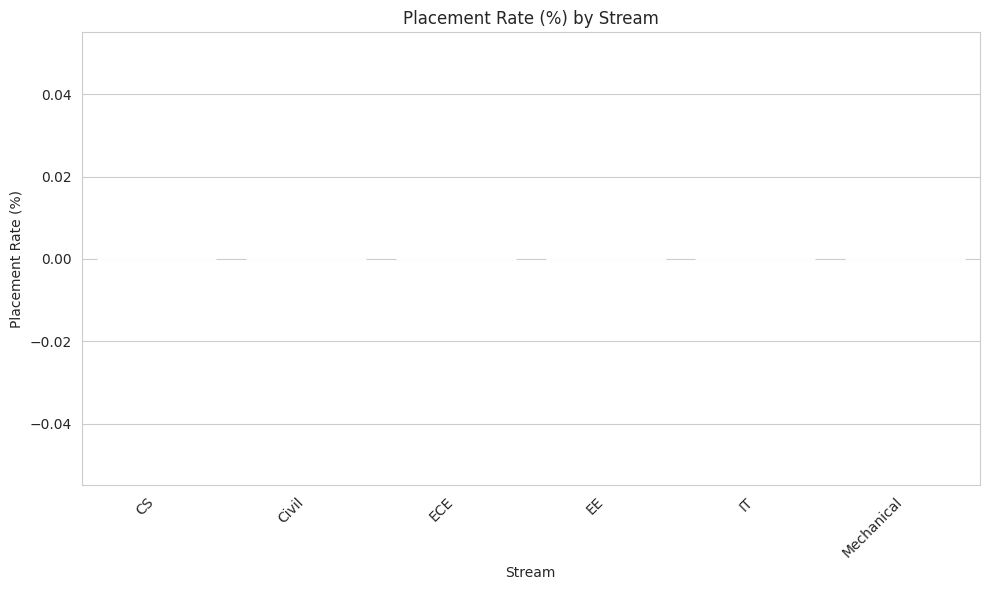


Placement rate (%) by stream:
Stream
CS            0.0
Civil         0.0
ECE           0.0
EE            0.0
IT            0.0
Mechanical    0.0
Name: Placed_Flag, dtype: float64


In [12]:

fig3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False) * 100
)

sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPlacement rate (%) by stream:")
print(placement_rate.round(2))

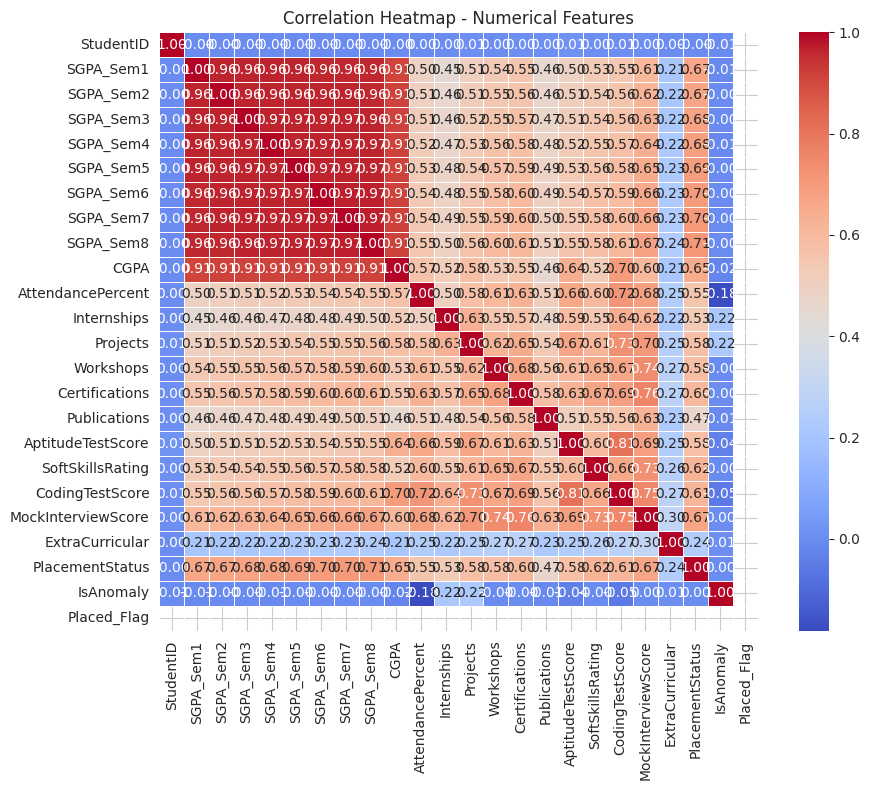

In [13]:

fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

KeyError: 'Salary Package'

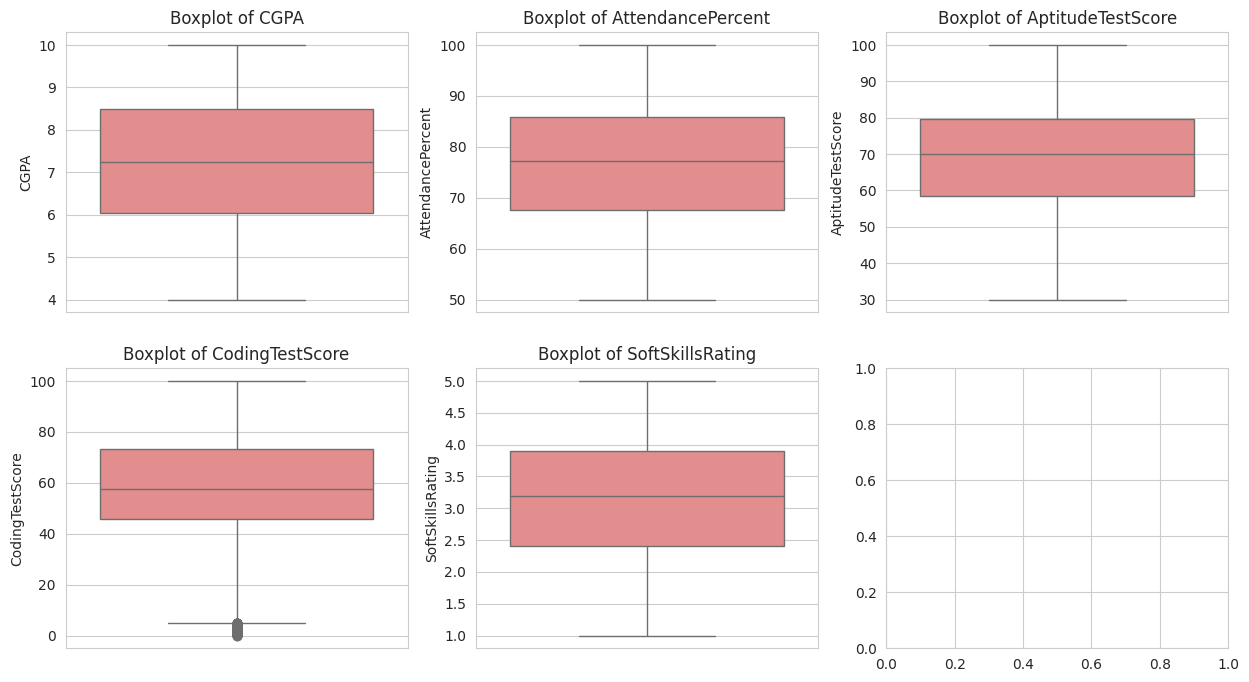

In [14]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [16]:

pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms
pdf.savefig(fig3)   # Page 3: Placement Rate by Stream
pdf.savefig(fig4)   # Page 4: Correlation Heatmap
pdf.savefig(fig5)   # Page 5: Boxplots

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")


EDA_Report.pdf created successfully with 5 pages!


In [17]:

files.download('EDA_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>